In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
import itertools
import sys
sys.path.insert(0, os.path.dirname(os.getcwd()))
import liset_tk.lists_sessions as lists_sessions
# Set style
sns.set_style("whitegrid")
# plt.rcParams.update({'font.size': 12})
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Load Data
results_path = os.path.join("spikes", "all_networks_metrics_ripplAI.csv")

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    print(f"Loaded {len(df)} rows from {results_path}")
    
    # Preprocessing
    # Rename ADAPT to Adapt for consistency
    if "ADAPT" in df.columns:
        df.rename(columns={"ADAPT": "Adapt"}, inplace=True)
        
    print("Columns:", df.columns.tolist())
    print("Threshold:", sorted(df["Threshold"].unique()))
    
    display(df.head())
else:
    print(f"File not found: {results_path}. Please run process_live_spikes.py first.")

Loaded 2925 rows from spikes\all_networks_metrics_ripplAI.csv
Columns: ['Session', 'Channel', 'Threshold', 'Model', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1', 'Mean_Latency', 'Num_Spikes', 'Num_Ripples']
Threshold: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


,Session,Channel,Threshold,Model,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples
0,2025-09-22_17-42-27,24,0.1,CNN1D_1,96,256,13,0.272727,0.880734,0.416486,10.148958,421,109
1,2025-09-22_17-42-27,24,0.1,CNN1D_2,61,17,48,0.782051,0.559633,0.652406,13.282514,82,109
2,2025-09-22_17-42-27,24,0.1,CNN1D_3,81,54,28,0.600000,0.743119,0.663934,7.340741,142,109
3,2025-09-22_17-42-27,24,0.1,CNN1D_4,73,40,36,0.646018,0.669725,0.657658,9.045662,116,109
4,2025-09-22_17-42-27,24,0.1,CNN1D_5,87,207,22,0.295918,0.798165,0.431762,7.213410,324,109


In [3]:
hfo_sessions = lists_sessions.HFO_sessions
ripple_sessions = lists_sessions.Ripple_sessions

sessions_to_reject={
    "2025-09-24_14-22-55", #H
    # "2025-09-24_16-29-07", #R   # Nothing concrete to reject here
        # "2025-09-24_17-38-17", # Barely any ripples (14 in total...)
        # "2025-09-25_12-52-22", # Not a good session to detect ripples
        # #  "2025-09-24_11-34-51", # Nothing concrete
        } #R 
# og_session_set={"2025-09-22_17-55-26", #R
# #                 "2025-09-23_15-50-26", #R
# #                 "2025-09-24_10-24-40", #R
# #                 "2025-09-24_14-22-55", #H
# #                 "2025-09-24_15-13-10", #H
# #                 "2025-09-25_16-41-14"} #R    
# }
sessions_to_reject.update(hfo_sessions)

    # df=df[df["Session"].isin(og_session_set)]

    # # New sessions:

    

df=df[~df["Session"].isin(sessions_to_reject)]
print(df["Session"].unique())
# df=df[~df["Session"].isin(ripple_sessions)]

['2025-09-22_17-42-27' '2025-09-22_17-55-26' '2025-09-23_15-50-26'
 '2025-09-23_16-17-52' '2025-09-24_10-24-40' '2025-09-24_11-34-51'
 '2025-09-24_16-29-07' '2025-09-24_17-38-17' '2025-09-25_11-21-53'
 '2025-09-25_12-52-22' '2025-09-25_16-41-14']


In [4]:
# Print summary
print("\n--- Summary by Network ---")
summary = df.groupby("Threshold")[["F1", "Precision", "Recall", "TP", "FP", "FN"]].mean().round(3).sort_values(by="F1", ascending=False)
display(summary)


--- Summary by Network ---


,F1,Precision,Recall,TP,FP,FN
Threshold,,,,,,
0.3,0.323,0.427,0.394,43.491,85.615,58.055
0.2,0.312,0.342,0.494,54.098,179.825,47.447
0.4,0.311,0.490,0.321,35.447,46.989,66.098
0.5,0.282,0.514,0.257,28.531,27.538,73.015
0.1,0.262,0.227,0.657,70.345,522.785,31.200
0.6,0.247,0.540,0.203,22.593,16.284,78.953
0.7,0.208,0.520,0.155,17.345,8.840,84.200
0.8,0.159,0.477,0.107,12.204,4.022,89.342
0.9,0.100,0.455,0.061,7.236,1.193,94.309


In [5]:
df['Model'] = df['Model'].str.extract(r'(CNN1D|CNN2D|LSTM|SVM|XGBOOST)', expand=False)
# Print summary by Threshold and Model
print("\n--- Summary by Threshold and Model ---")
summary = df.groupby(['Threshold', 'Model'])[["F1", "Precision", "Recall", "TP", "FP", "FN"]].median().round(3)
display(summary)


--- Summary by Threshold and Model ---


F1  Precision  Recall    TP     FP    FN
Threshold Model                                               
0.1       CNN1D    0.401      0.333   0.604  56.0   61.0  44.0
          CNN2D    0.256      0.236   0.403  33.0   54.0  53.0
          LSTM     0.311      0.225   0.800  75.0  190.0  17.0
          SVM      0.151      0.083   0.867  83.0  697.0  11.0
          XGBOOST  0.142      0.080   0.902  80.0  986.0  11.0
0.2       CNN1D    0.400      0.478   0.467  44.0   23.0  48.0
          CNN2D    0.276      0.402   0.225  21.0   15.0  64.0
          LSTM     0.440      0.458   0.467  51.0   35.0  43.0
          SVM      0.254      0.171   0.634  58.0  216.0  31.0
          XGBOOST  0.263      0.156   0.848  72.0  395.0  17.0
0.3       CNN1D    0.400      0.552   0.337  35.0   12.0  58.0
          CNN2D    0.171      0.500   0.133  11.0    6.0  70.0
          LSTM     0.413      0.638   0.333  32.0   14.0  56.0
          SVM      0.255      0.242   0.443  35.0   80.0  48.0
          XGBOOST  0.353      0.223   0.784  65.0  197.0  26.0
0.4       CNN1D    0.340      0.636   0.292  23.0    8.0  66.0
          CNN2D    0.129      0.545   0.076   5.0    4.0  71.0
          LSTM     0.369      0.722   0.267  21.0    8.0  70.0
          SVM      0.280      0.353   0.333  25.0   36.0  55.0
          XGBOOST  0.416      0.315   0.676  59.0  113.0  34.0
0.5       CNN1D    0.268      0.750   0.223  15.0    6.0  72.0
          CNN2D    0.071      0.588   0.037   4.0    2.0  72.0
          LSTM     0.303      0.809   0.183  14.0    3.0  72.0
          SVM      0.279      0.450   0.254  16.0   20.0  64.0
          XGBOOST  0.469      0.411   0.584  53.0   64.0  42.0
0.6       CNN1D    0.211      0.778   0.141  11.0    3.0  75.0
          CNN2D    0.028      0.581   0.014   1.0    1.0  77.0
          LSTM     0.204      0.882   0.119   7.0    1.0  72.0
          SVM      0.254      0.529   0.178  10.0   10.0  71.0
          XGBOOST  0.483      0.484   0.479  39.0   38.0  49.0
0.7       CNN1D    0.177      0.685   0.130   8.0    1.0  80.0
          CNN2D    0.000      0.000   0.000   0.0    0.0  81.0
          LSTM     0.076      0.920   0.040   2.0    0.0  82.0
          SVM      0.208      0.525   0.130   6.0    6.0  73.0
          XGBOOST  0.483      0.600   0.391  25.0   20.0  61.0
0.8       CNN1D    0.120      0.714   0.067   4.0    1.0  83.0
          CNN2D    0.000      0.000   0.000   0.0    0.0  89.0
          LSTM     0.000      0.000   0.000   0.0    0.0  86.0
          SVM      0.160      0.643   0.099   5.0    2.0  79.0
          XGBOOST  0.417      0.733   0.275  17.0    7.0  71.0
0.9       CNN1D    0.022      0.750   0.011   1.0    0.0  87.0
          CNN2D    0.000      0.000   0.000   0.0    0.0  92.0
          LSTM     0.000      0.000   0.000   0.0    0.0  92.0
          SVM      0.093      0.667   0.049   3.0    1.0  86.0
          XGBOOST  0.260      0.880   0.150   9.0    1.0  72.0

In [6]:
print(summary.loc[summary["F1"].idxmax()])

F1            0.483
Precision     0.484
Recall        0.479
TP           39.000
FP           38.000
FN           49.000
Name: (0.6, XGBOOST), dtype: float64


In [7]:
# Print summary
print("\n--- Summary by Session ---")
summary = df[(df["Threshold"]==0.5) & (df["Model"]=="XGBOOST")].groupby("Session")[["F1", "Precision", "Recall", "TP", "FP", "FN"]].mean().round(3).sort_values(by="F1", ascending=False)
display(summary)


--- Summary by Session ---


,F1,Precision,Recall,TP,FP,FN
Session,,,,,,
2025-09-22_17-55-26,0.651,0.731,0.606,112.2,46.4,72.8
2025-09-22_17-42-27,0.605,0.577,0.670,73.0,60.2,36.0
2025-09-25_11-21-53,0.580,0.630,0.564,114.0,72.6,88.0
2025-09-25_16-41-14,0.562,0.499,0.672,96.8,104.0,47.2
2025-09-23_15-50-26,0.553,0.495,0.681,94.6,111.8,44.4
2025-09-24_16-29-07,0.477,0.380,0.715,28.6,54.2,11.4
2025-09-24_17-38-17,0.389,0.315,0.587,8.8,22.8,6.2
2025-09-24_10-24-40,0.368,0.303,0.539,49.6,130.2,42.4
2025-09-24_11-34-51,0.332,0.288,0.462,32.8,97.2,38.2


In [8]:
def barplot_annotate_brackets(num1, num2, data, center, height, ax, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=None):
    """ 
    Annotate barplot with p-values. 
    Adapted from the provided script.
    """
    if type(data) is str:
        text = data
    else:
        if data > 0.05:
          return
        text = ''
        p = .05
        while data < p:
            text += '*'
            p /= 10.
            if maxasterix and len(text) == maxasterix:
                break
        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    ax.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    ax.text(*mid, text, **kwargs)

N=11 matched samples for statistics.
0.1 vs 0.2: p=0.0098
0.1 vs 0.3: p=0.0244


C:\Users\NCN\AppData\Local\Temp\ipykernel_28268\2978177946.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette="viridis", width=0.5, showfliers=False, order=adapt_values)


0.1 vs 0.8: p=0.0068
0.1 vs 0.9: p=0.0020
0.2 vs 0.6: p=0.0098
0.2 vs 0.7: p=0.0029
0.2 vs 0.8: p=0.0010
0.2 vs 0.9: p=0.0010
0.3 vs 0.5: p=0.0049
0.3 vs 0.6: p=0.0010
0.3 vs 0.7: p=0.0010
0.3 vs 0.8: p=0.0010
0.3 vs 0.9: p=0.0010
0.4 vs 0.5: p=0.0020
0.4 vs 0.6: p=0.0010
0.4 vs 0.7: p=0.0010
0.4 vs 0.8: p=0.0010
0.4 vs 0.9: p=0.0010
0.5 vs 0.6: p=0.0010
0.5 vs 0.7: p=0.0010
0.5 vs 0.8: p=0.0010
0.5 vs 0.9: p=0.0010
0.6 vs 0.7: p=0.0010
0.6 vs 0.8: p=0.0010
0.6 vs 0.9: p=0.0010
0.7 vs 0.8: p=0.0010
0.7 vs 0.9: p=0.0010
0.8 vs 0.9: p=0.0010


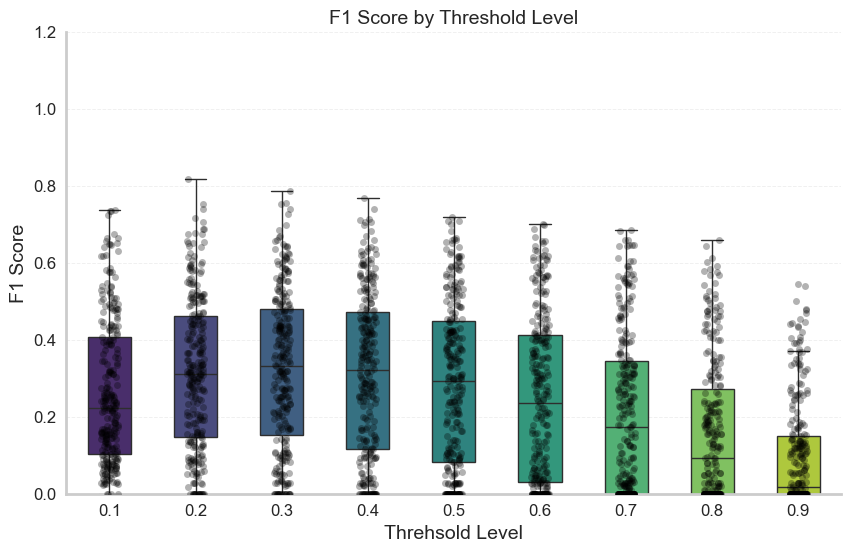

In [9]:
def plot_f1_boxplot_by_adapt(df, metric="F1", aggregate_by_network=False):
    # Define specific order
    # desired_order = [0, 120, 20, 2]
    # # Filter to only include values present in the dataframe
    # adapt_values = [a for a in desired_order if a in df["Threshold"].unique()]
    adapt_values = sorted(df["Threshold"].unique())
    # Data preparation
    if aggregate_by_network:
        # Average over sessions/channels for each network
        plot_df = df.groupby(["Network", "Threshold"])[metric].mean().reset_index()
        title_suffix = " (Averaged by Network)"
        print(f"Aggregated by network. N={len(plot_df['Network'].unique())} networks.")
    else:
        plot_df = df
        title_suffix = ""

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Boxplot
    sns.boxplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette="viridis", width=0.5, showfliers=False, order=adapt_values)
    sns.stripplot(x="Threshold", y=metric, data=plot_df, ax=ax, color="black", alpha=0.3, jitter=True, order=adapt_values)
    
    # Statistical annotation (Wilcoxon)
    if aggregate_by_network:
        pivot_cols = ["Network"]
    else:
        pivot_cols = ["Session", "Channel",]
        
    pivot = plot_df.pivot_table(index=pivot_cols, columns="Threshold", values=metric)
    pivot = pivot.dropna()
    print(f"N={len(pivot)} matched samples for statistics.")
    
    if len(pivot) > 0:
        centers = range(len(adapt_values))
        # Calculate max height for annotations
        max_val = plot_df[metric].max()
        
        combinations = list(itertools.combinations(range(len(adapt_values)), 2))
        for idx, (i, j) in enumerate(combinations):
            a1 = adapt_values[i]
            a2 = adapt_values[j]
            
            v1 = pivot[a1].values
            v2 = pivot[a2].values
            
            # Check if we have enough samples for Wilcoxon
            if len(v1) >= 3:
                stat, p = wilcoxon(v1, v2)
                
                # Stacking logic for brackets
                h = max_val + 0.05 * (1 + idx) * (max_val * 0.1)
                
                if p < 0.05:
                    print(f"{a1} vs {a2}: p={p:.4f}")
                    # barplot_annotate_brackets(i, j, p, centers, [h]*len(centers), ax)
            else:
                print(f"Skipping stats for {a1} vs {a2}: N={len(v1)} too small")
    
    ax.grid(True, axis='y', linestyle='--',linewidth=0.7,alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)           
    ax.set_title(f"{metric} Score by Threshold Level{title_suffix}",fontsize=14)
    ax.set_ylim(0, 1.2) # Adjust to fit brackets
    ax.set_ylabel(f"{metric} Score",fontsize=14)
    ax.set_xlabel("Threhsold Level",fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    plt.show()

if 'df' in locals():
    plot_f1_boxplot_by_adapt(df, "F1", aggregate_by_network=False)

C:\Users\NCN\AppData\Local\Temp\ipykernel_28268\3967043615.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=adapt_values)
C:\Users\NCN\AppData\Local\Temp\ipykernel_28268\3967043615.py:23: UserWarning: 
The palette list has fewer values (4) than needed (9) and will cycle, which may produce an uninterpretable plot.
  sns.violinplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=adapt_values)


0.1 vs 0.2: p=0.1230
0.1 vs 0.3: p=0.2061
0.1 vs 0.4: p=0.7002
0.1 vs 0.5: p=0.7002
0.1 vs 0.6: p=0.0674
0.1 vs 0.7: p=0.0010
0.1 vs 0.8: p=0.0010
0.1 vs 0.9: p=0.0010
0.2 vs 0.3: p=0.9658
0.2 vs 0.4: p=0.1016
0.2 vs 0.5: p=0.0068
0.2 vs 0.6: p=0.0010
0.2 vs 0.7: p=0.0010
0.2 vs 0.8: p=0.0010
0.2 vs 0.9: p=0.0010
0.3 vs 0.4: p=0.0029
0.3 vs 0.5: p=0.0010
0.3 vs 0.6: p=0.0010
0.3 vs 0.7: p=0.0010
0.3 vs 0.8: p=0.0010
0.3 vs 0.9: p=0.0010
0.4 vs 0.5: p=0.0051
0.4 vs 0.6: p=0.0051
0.4 vs 0.7: p=0.0051
0.4 vs 0.8: p=0.0051
0.4 vs 0.9: p=0.0051
0.5 vs 0.6: p=0.0051
0.5 vs 0.7: p=0.0051
0.5 vs 0.8: p=0.0051
0.5 vs 0.9: p=0.0051
0.6 vs 0.7: p=0.0077
0.6 vs 0.8: p=0.0077
0.6 vs 0.9: p=0.0077
0.7 vs 0.8: p=0.0077
0.7 vs 0.9: p=0.0077
0.8 vs 0.9: p=0.0077


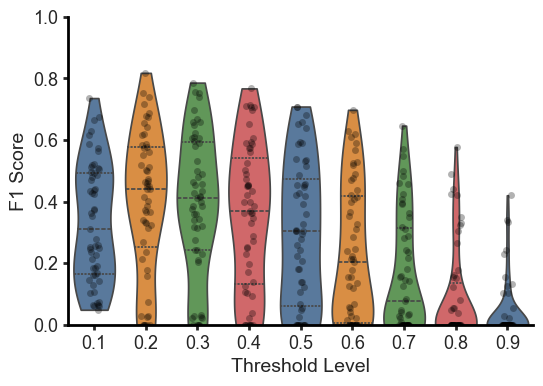

In [10]:
def plot_f1_violin_by_adapt(df, metric="F1", aggregate_by_network=False):
    # Define specific order
    # desired_order = [0, 120, 20, 2]
    # Filter to only include values present in the dataframe
    # adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    adapt_values = sorted(df["Threshold"].unique())

    # Data preparation
    if aggregate_by_network:
        # Average over sessions/channels for each network
        plot_df = df.groupby(["Network", "Threshold"])[metric].mean().reset_index()
        title_suffix = " (Averaged by Network)"
        print(f"Aggregated by network. N={len(plot_df['Network'].unique())} networks.")
    else:
        plot_df = df
        title_suffix = ""

    fig, ax = plt.subplots(figsize=(6, 4))
    
    colors=["#4E79A7", "#F28E2B", "#59A14F", "#E15759"]

    # Violin plot
    sns.violinplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=adapt_values)
    # Overlay points
    sns.stripplot(x="Threshold", y=metric, data=plot_df, ax=ax, color="black", alpha=0.3, jitter=True, order=adapt_values)
    
    # Statistical annotation (Wilcoxon)
    if aggregate_by_network:
        pivot_cols = ["Network"]
    else:
        pivot_cols = ["Session", "Channel",]
        
    pivot = plot_df.pivot_table(index=pivot_cols, columns="Threshold", values=metric)
    # display(pivot.head())
    pivot = pivot.dropna()

    # Annotate medians and N
    medians = plot_df.groupby('Threshold')[metric].median()
    counts = plot_df.groupby('Threshold')[metric].count()
    mins=plot_df.groupby('Threshold')[metric].min() 
        
    for i, adapt in enumerate(adapt_values):
        if adapt in medians:
            val = medians[adapt]
            min_val = mins[adapt]
            # ax.text(i, min_val- 0.1, f'M={val:.2f}',  
            # ha='center', va='bottom', fontsize=12, color='black')

    if len(pivot) > 0:
        centers = range(len(adapt_values))
        max_val = plot_df[metric].max()
        
        combinations = list(itertools.combinations(range(len(adapt_values)), 2))
        for idx, (i, j) in enumerate(combinations):
            a1 = adapt_values[i]
            a2 = adapt_values[j]
            
            v1 = pivot[a1].values
            v2 = pivot[a2].values
            
            # Check if we have enough samples for Wilcoxon
            if len(v1) >= 3: 
                stat, p = wilcoxon(v1, v2)
                
                # Stacking logic for brackets
                h = max_val + 0.05 * (1 + idx) * (max_val * 0.1)
                
                print(f"{a1} vs {a2}: p={p:.4f}")
                # barplot_annotate_brackets(i, j, p, centers, [h]*len(centers), ax)
            else:
                print(f"Skipping stats for {a1} vs {a2}: N={len(v1)} too small")
                
    # ax.set_title(f"{metric} Distribution by Adaptation Level{title_suffix}")
    ax.set_ylim(0,1) 

    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(1.3)
    ax.spines[['bottom','left']].set_color('black')
    # ax.set_xticklabels(["Fixed","60", "10", "1"])
    ax.tick_params(axis='both', which='major', labelsize=13, bottom=True, left=True,width=2)
    ax.tick_params(axis='x', rotation=0)

    ax.set_ylabel(f"{metric} Score",fontsize=14)
    ax.set_xlabel("Threshold Level",fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=13)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    plt.show()
    return fig,ax

if 'df' in locals():
    df_plot=df[df["Model"]=="LSTM"]
    fig,ax=plot_f1_violin_by_adapt(df_plot, "F1", aggregate_by_network=False)
    os.makedirs("figures", exist_ok=True)
    # fig.savefig("figures/f1_violin_by_adapt.svg", dpi=300, bbox_inches='tight')
    # fig.savefig("figures/f1_violin_by_adapt.png",dpi=300)

C:\Users\NCN\AppData\Local\Temp\ipykernel_28268\1127962853.py:28: RuntimeWarning: divide by zero encountered in divide
  y = (f1 * x) / (2 * x - f1)


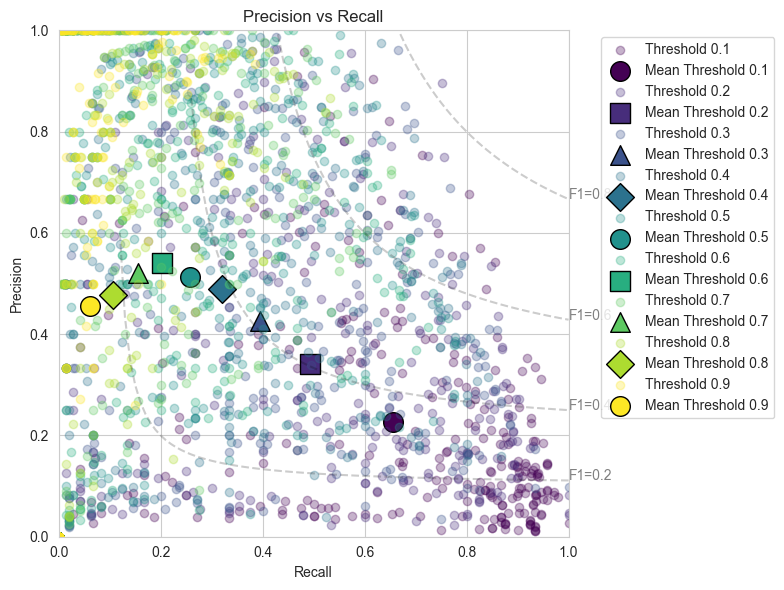

In [11]:
def plot_precision_recall(df):
    plt.figure(figsize=(8, 6))
    
    #  # Define specific order
    # desired_order = [0, 120, 20, 2]
    # # Filter to only include values present in the dataframe
    # adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    adapt_values = sorted(df["Threshold"].unique())
    
    markers = ['o', 's', '^', 'D']
    colors = plt.cm.viridis(np.linspace(0, 1, len(adapt_values)))
    
    for i, adapt in enumerate(adapt_values):
        subset = df[df["Threshold"] == adapt]
        
        # Mean point
        mean_p = subset["Precision"].mean()
        mean_r = subset["Recall"].mean()
        
        plt.scatter(subset["Recall"], subset["Precision"], label=f"Threshold {adapt}", alpha=0.3, color=colors[i])
        plt.scatter(mean_r, mean_p, s=200, edgecolor='black', marker=markers[i%len(markers)], 
                    label=f"Mean Threshold {adapt}", color=colors[i])
        
    # F1 isolines
    f1_scores = [0.2, 0.4, 0.6, 0.8]
    x = np.linspace(0.01, 1, 100)
    for f1 in f1_scores:
        y = (f1 * x) / (2 * x - f1)
        # Filter valid y
        valid = (y >= 0) & (y <= 1)
        plt.plot(x[valid], y[valid], 'k--', alpha=0.2)
        if any(valid):
            plt.text(x[valid][-1], y[valid][-1], f"F1={f1}", color='gray')
        
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision vs Recall")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if 'df' in locals():
    plot_precision_recall(df)

In [12]:
def plot_relative_change(df, metric="F1"):
    # Pivot to have Adapt as columns
    pivot_cols = ["Session", "Channel",]
    if "Dataset" in df.columns:
        pivot_cols.append("Dataset")
        
    pivot = df.pivot_table(index=pivot_cols, columns="Threshold", values=metric) # Pivot table
    # print(pivot.head())
    # Calculate change relative to Adapt 0 (or lowest adapt value)
     # Define specific order
    desired_order = [0, 120, 20, 2]
    # # Filter to only include values present in the dataframe
    # adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    adapt_values= sorted(df["Threshold"].unique())
    baseline_adapt = 3.0
    
    if baseline_adapt not in pivot.columns:
        print(f"Baseline adapt {baseline_adapt} not found in pivot columns.")
        return

    changes = pd.DataFrame()
    for col in pivot.columns:
        changes[col] = (pivot[col] - pivot[baseline_adapt]) / pivot[baseline_adapt] * 100
        
    # Melt for plotting
    melted = changes.melt(var_name="Threshold", value_name="Percent Change")
    # print(melted)
    plt.figure(figsize=(10, 6))
    sns.boxplot(x="Threshold", y="Percent Change", data=melted, palette="coolwarm", order=adapt_values)
    # Overlay points
    sns.stripplot(x="Threshold", y="Percent Change", data=melted, color="black", alpha=0.3, jitter=True, order=adapt_values)

    plt.axhline(0, color='black', linestyle='--')
    plt.title(f"Relative Change in {metric} (%) compared to Threshold {baseline_adapt}")
    plt.ylabel(f"% Change in {metric}")
    plt.show()

if 'df' in locals():
    plot_relative_change(df, "F1")

Baseline adapt 3.0 not found in pivot columns.


,Session,Channel,Threshold,Metric,Value
0,2025-09-22_17-42-27,24,0.5,Precision,0.784091
1,2025-09-22_17-42-27,24,0.5,Precision,1.000000
2,2025-09-22_17-42-27,24,0.5,Precision,0.860000
3,2025-09-22_17-42-27,24,0.5,Precision,0.911111
4,2025-09-22_17-42-27,24,0.5,Precision,0.717647


C:\Users\NCN\AppData\Local\Temp\ipykernel_28268\1095338557.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Metric', y='Value', data=melted, ax=ax, palette='viridis', inner='quartile', cut=0, order=order,alpha=.8,linewidth=2)


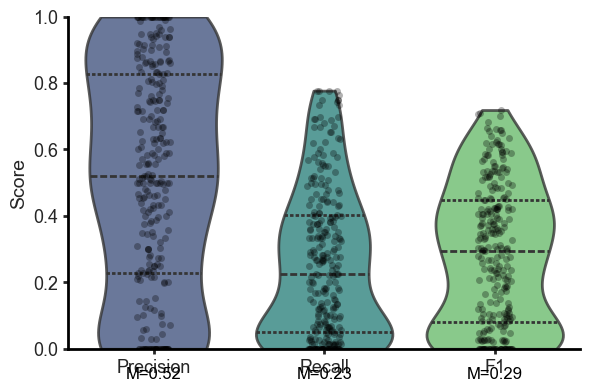

In [13]:
# Plot Precision, Recall and F1 for a single Adaptation level in the same figure
def plot_metrics_single_adapt(df, adapt=20, aggregate_by_network=False, metrics=("Precision", "Recall", "F1")):
    """Plot the distributions of multiple metrics for a single `adapt` value in one plot."""
    # Ensure adapt exists in the dataframe
    if adapt not in df["Threshold"].unique():
        print(f"Adapt {adapt} not present in dataframe. Available: {sorted(df['Threshold'].unique())}")
        return

    # Prepare data for the requested adapt
    if aggregate_by_network:
        agg_cols = ['Network', 'Adapt']
        plot_df = df.groupby(agg_cols)[list(metrics)].mean().reset_index()
        title_suffix = ' (Averaged by Network)'
    else:
        plot_df = df.copy()
        title_suffix = ''

    plot_df = plot_df[plot_df['Threshold'] == adapt]
    if len(plot_df) == 0:
        print(f'No rows for Threshold {adapt} after filtering.')
        return

    # Melt metrics into long form for plotting
    id_vars = [c for c in ['Session', 'Channel', 'Threshold'] if c in plot_df.columns]
    melted = plot_df.melt(id_vars=id_vars, value_vars=list(metrics), var_name='Metric', value_name='Value')
    display(melted.head())
    # Plot
    fig, ax = plt.subplots(figsize=(6, 4))
    order = list(metrics)
    sns.violinplot(x='Metric', y='Value', data=melted, ax=ax, palette='viridis', inner='quartile', cut=0, order=order,alpha=.8,linewidth=2)
    sns.stripplot(x='Metric', y='Value', data=melted, ax=ax, color='k', alpha=0.3, jitter=True, order=order)

    # Annotate medians and N
    medians = melted.groupby('Metric')['Value'].median()
    counts = melted.groupby('Metric')['Value'].count()
    mins=melted.groupby('Metric')['Value'].min() 
    
    for i, metric in enumerate(order):
        if metric in medians:
            val = medians[metric]
            min_val = mins[metric]
            ax.text(i, min_val- 0.1, f'M={val:.2f}',  
            ha='center', va='bottom', fontsize=12, color='black')

    ax.set_ylim(0, 1)
    # ax.set_title(f'Performance Metrics', fontsize=14)
    ax.set_ylabel('Score', fontsize=14)
    ax.set_xlabel('')
    # ax.set_xlabel('Metric', fontsize=14)
    # ax.grid(True, axis='y', linestyle='--', linewidth=0.6, alpha=0.4)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(2)
    ax.spines[['bottom','left']].set_color('black')

    ax.tick_params(axis='both', which='major', labelsize=13, bottom=True, left=True,width=2.0)
    ax.tick_params(axis='x', rotation=0)
    # ax.set_yticks(np.arange(0.3, 1.1, 0.1))
    plt.tight_layout()
    plt.show()
    return fig, ax

if 'df' in locals():
    fig,ax=plot_metrics_single_adapt(df, adapt=0.5, aggregate_by_network=False)
    # plot_f1_violin_by_adapt(df, "F1", aggregate_by_network=False)
    # fig.savefig("figures/metrics_single_adapt.svg", format="svg")
    # fig.savefig("figures/metrics_single_adapt.png", format="png", dpi=300)

In [14]:
def display_adaptive_threshold_analysis(
    df,
    result_aggregation="median",
    pick_best_row=False,
    merge_back=True,
    verbose=False
):
    """
    Analyzes adaptive threshold performance, standardized to match get_best_per_session_df logic.

    Args:
        df: DataFrame containing metrics.
        result_aggregation: How to summarize the final collection of per-session values ('mean', 'median', 'max').
        pick_best_row: 
            - True: Represents each session by its single best channel (row) after filtering for best threshold.
            - False: Represents each session by the median of all channels (rows) after filtering for best threshold.
        merge_back:
            - True (Required for pick_best_row logic): Merges best threshold back to original data to access channels.
    """

    print(
        f"--- Adaptive Analysis | Pick Best Row: {pick_best_row} | "
        f"Merge Back: {merge_back} | Final Aggregation: {result_aggregation} ---"
    )

    optimized_results = []
    # Metrics to track
    metrics_to_agg = ['F1', 'Precision', 'Recall', 'TP', 'FP', 'FN']
    metrics_to_agg = [m for m in metrics_to_agg if m in df.columns]

    models = df['Model'].unique()

    for model in models:
        if verbose:
            print(f"\nProcessing Model: {model}")
        model_df = df[df['Model'] == model].copy()

        # --- STEP 1: Determine Best Threshold per Session ---
        # Logic: Maximizing MEDIAN F1 across channels for the threshold
        # (This matches get_best_per_session_df Step 1 & 2)
        
        # 1. Aggregate metric by (Session, Threshold)
        grouped = (
            model_df
            .groupby(['Session', 'Threshold'])["F1"]
            .median()
            .reset_index()
        )
        
        # 2. Find Best Config (Threshold) per Session
        best_cfg = (
            grouped
            .sort_values("F1", ascending=False)
            .drop_duplicates(subset=["Session"])
        )
        # best_cfg now contains [Session, Threshold] pairs that are "Optimal"

        # --- STEP 2: Retrieve Full Data for Best Configs ---
        # (Matches matches get_best_per_session_df Step 3)

        if merge_back:
            # Re-join with original data to get ALL rows (channels) for the chosen (Session, Threshold) pairs
            out = model_df.merge(
                best_cfg[['Session', 'Threshold']],
                on=['Session', 'Threshold'],
                how='inner'
            )
        else:
            # Fallback (rarely used given requirements): just use the aggregated values from finding step
            # Note: This loses precision/recall/TP info if not carried over
            out = best_cfg
            
        # --- STEP 3: Reduce to One Row Per Session ---
        # (Matches get_best_per_session_df Step 4)

        if pick_best_row and merge_back:
            # Option A: Pick the SINGLE BEST channel/row for that session
            per_session_df = (
                out
                .sort_values("F1", ascending=False)
                .drop_duplicates(subset=["Session"])
            )
        else:
            # Option B: Aggregate (Median) all channels for that session
            # This collapses the distribution of channels into one median vector per session
            per_session_df = (
                out
                .groupby("Session")[metrics_to_agg]
                .median()
                .reset_index()
            )
        if verbose:
            print(f"Number of sessions: {len(per_session_df)}")
            display(per_session_df)
        # --- STEP 4: Global Aggregation across Sessions ---
        # Summarize the per_session_df into one row for the table
        
        if result_aggregation == 'mean':
            agg_perf = per_session_df[metrics_to_agg].mean()
        elif result_aggregation == 'median':
            agg_perf = per_session_df[metrics_to_agg].median()
        elif result_aggregation == 'max':
            agg_perf = per_session_df[metrics_to_agg].max()
        else:
            agg_perf = per_session_df[metrics_to_agg].agg(result_aggregation)

        agg_perf['Model'] = model
        optimized_results.append(agg_perf)

    summary = pd.DataFrame(optimized_results)
    if not summary.empty:
        cols = ['Model'] + metrics_to_agg
        summary = summary[cols].sort_values(by='F1', ascending=False)
        display(summary.round(3))
    else:
        print("No data found.")

In [15]:
# Load RipplAI Data
results_path = os.path.join("spikes", "all_networks_metrics_ripplAI.csv")

if os.path.exists(results_path):
    ripplAI_df = pd.read_csv(results_path)
    print(f"Loaded {len(ripplAI_df)} rows from {results_path}")
    
    # Preprocessing
    # Rename ADAPT to Adapt for consistency
    if "ADAPT" in ripplAI_df.columns:
        ripplAI_df.rename(columns={"ADAPT": "Adapt"}, inplace=True)
    
    ripplAI_df['Model'] = ripplAI_df['Model'].str.extract(r'(CNN1D|CNN2D|LSTM|SVM|XGBOOST)', expand=False)

    print("Columns:", ripplAI_df.columns.tolist())
    print("Threshold:", sorted(ripplAI_df["Threshold"].unique()))
    
    display(ripplAI_df.head())
else:
    print(f"File not found: {results_path}. Please run process_live_spikes.py first.")

Loaded 2925 rows from spikes\all_networks_metrics_ripplAI.csv
Columns: ['Session', 'Channel', 'Threshold', 'Model', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1', 'Mean_Latency', 'Num_Spikes', 'Num_Ripples']
Threshold: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


,Session,Channel,Threshold,Model,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples
0,2025-09-22_17-42-27,24,0.1,CNN1D,96,256,13,0.272727,0.880734,0.416486,10.148958,421,109
1,2025-09-22_17-42-27,24,0.1,CNN1D,61,17,48,0.782051,0.559633,0.652406,13.282514,82,109
2,2025-09-22_17-42-27,24,0.1,CNN1D,81,54,28,0.600000,0.743119,0.663934,7.340741,142,109
3,2025-09-22_17-42-27,24,0.1,CNN1D,73,40,36,0.646018,0.669725,0.657658,9.045662,116,109
4,2025-09-22_17-42-27,24,0.1,CNN1D,87,207,22,0.295918,0.798165,0.431762,7.213410,324,109


In [16]:
hfo_sessions = lists_sessions.HFO_sessions
ripple_sessions = lists_sessions.Ripple_sessions



sessions_to_reject={
    # "2025-09-24_16-29-07", #R   # Nothing concrete to reject here
        "2025-09-24_17-38-17", # Barely any ripples (14 in total...)
        "2025-09-25_12-52-22", # Not a good session to detect ripples
        #  "2025-09-24_11-34-51",
        } #R 

sessions_to_reject.update(hfo_sessions)
ripplAI_df=ripplAI_df[~ripplAI_df["Session"].isin(sessions_to_reject)]

In [17]:
display_adaptive_threshold_analysis(
    ripplAI_df,
    result_aggregation="median",
    pick_best_row=False,
    merge_back=True,
    verbose=True
)

--- Adaptive Analysis | Pick Best Row: False | Merge Back: True | Final Aggregation: median ---

Processing Model: CNN1D
Number of sessions: 9


,Session,F1,Precision,Recall,TP,FP,FN
0,2025-09-22_17-42-27,0.652406,0.600000,0.743119,81.0,54.0,28.0
1,2025-09-22_17-55-26,0.725076,0.754286,0.713514,132.0,43.0,53.0
2,2025-09-23_15-50-26,0.536398,0.573770,0.568345,79.0,56.0,60.0
3,2025-09-23_16-17-52,0.158730,0.212500,0.097222,7.0,9.0,65.0
4,2025-09-24_10-24-40,0.311475,0.378947,0.434783,40.0,59.0,52.0
5,2025-09-24_11-34-51,0.473118,0.382609,0.619718,44.0,71.0,27.0
6,2025-09-24_16-29-07,0.389610,0.405405,0.550000,22.0,30.0,18.0
7,2025-09-25_11-21-53,0.460274,0.477912,0.495050,100.0,130.0,102.0
8,2025-09-25_16-41-14,0.581395,0.555000,0.604167,87.0,89.0,57.0



Processing Model: CNN2D
Number of sessions: 9


,Session,F1,Precision,Recall,TP,FP,FN
0,2025-09-22_17-42-27,0.254335,0.619048,0.201835,22.0,8.0,87.0
1,2025-09-22_17-55-26,0.528302,0.651376,0.454054,84.0,38.0,101.0
2,2025-09-23_15-50-26,0.493392,0.636364,0.482014,67.0,32.0,72.0
3,2025-09-23_16-17-52,0.218182,0.236111,0.236111,17.0,55.0,55.0
4,2025-09-24_10-24-40,0.273292,0.318841,0.304348,28.0,47.0,64.0
5,2025-09-24_11-34-51,0.097087,0.154519,0.070423,5.0,27.0,66.0
6,2025-09-24_16-29-07,0.231884,0.275362,0.200000,8.0,27.0,32.0
7,2025-09-25_11-21-53,0.430108,0.525000,0.381188,77.0,78.0,125.0
8,2025-09-25_16-41-14,0.441176,0.620000,0.319444,46.0,34.0,98.0



Processing Model: LSTM
Number of sessions: 9


...


Processing Model: SVM
Number of sessions: 9


,Session,F1,Precision,Recall,TP,FP,FN
0,2025-09-22_17-42-27,0.547170,0.604651,0.495413,54.0,36.0,55.0
1,2025-09-22_17-55-26,0.515723,0.616541,0.443243,82.0,51.0,103.0
2,2025-09-23_15-50-26,0.419476,0.437500,0.395683,55.0,72.0,84.0
3,2025-09-23_16-17-52,0.137500,0.125000,0.166667,12.0,77.0,60.0
4,2025-09-24_10-24-40,0.288210,0.248175,0.336957,31.0,88.0,61.0
5,2025-09-24_11-34-51,0.280488,0.247312,0.323944,23.0,70.0,48.0
6,2025-09-24_16-29-07,0.395062,0.390244,0.400000,16.0,26.0,24.0
7,2025-09-25_11-21-53,0.338983,0.230088,0.663366,134.0,443.0,68.0
8,2025-09-25_16-41-14,0.468665,0.385650,0.569444,82.0,137.0,62.0



Processing Model: XGBOOST
Number of sessions: 9


,Session,F1,Precision,Recall,TP,FP,FN
0,2025-09-22_17-42-27,0.659574,0.784810,0.568807,62.0,17.0,47.0
1,2025-09-22_17-55-26,0.658610,0.744828,0.589189,109.0,37.0,76.0
2,2025-09-23_15-50-26,0.583333,0.659794,0.503597,70.0,33.0,69.0
3,2025-09-23_16-17-52,0.125000,0.081081,0.263889,19.0,198.0,53.0
4,2025-09-24_10-24-40,0.391960,0.351351,0.423913,39.0,72.0,53.0
5,2025-09-24_11-34-51,0.319489,0.221591,0.591549,42.0,137.0,29.0
6,2025-09-24_16-29-07,0.527273,0.510204,0.675000,27.0,24.0,13.0
7,2025-09-25_11-21-53,0.602740,0.618280,0.589109,119.0,71.0,83.0
8,2025-09-25_16-41-14,0.564626,0.666667,0.500000,72.0,36.0,72.0


,Model,F1,Precision,Recall,TP,FP,FN
4,XGBOOST,0.565,0.618,0.569,62.0,37.0,53.0
2,LSTM,0.510,0.554,0.568,73.0,56.0,49.0
0,CNN1D,0.473,0.478,0.568,79.0,56.0,53.0
3,SVM,0.395,0.386,0.400,54.0,72.0,61.0
1,CNN2D,0.273,0.525,0.304,28.0,34.0,72.0


In [18]:
display_adaptive_threshold_analysis(
    ripplAI_df,
    result_aggregation="median",
    pick_best_row=True,
    merge_back=True,
    verbose=True    
)

--- Adaptive Analysis | Pick Best Row: True | Merge Back: True | Final Aggregation: median ---

Processing Model: CNN1D
Number of sessions: 9


,Session,Channel,Threshold,Model,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples
7,2025-09-22_17-55-26,26,0.1,CNN1D,132,43,53,0.754286,0.713514,0.733333,9.346212,179,185
2,2025-09-22_17-42-27,24,0.1,CNN1D,81,54,28,0.600000,0.743119,0.663934,7.340741,142,109
32,2025-09-25_16-41-14,21,0.1,CNN1D,111,89,33,0.555000,0.770833,0.645349,10.751351,208,144
12,2025-09-23_15-50-26,28,0.1,CNN1D,79,56,60,0.585185,0.568345,0.576642,10.316034,135,139
37,2025-09-25_11-21-53,21,0.2,CNN1D,119,130,83,0.477912,0.589109,0.527716,11.568627,261,202
28,2025-09-24_11-34-51,30,0.1,CNN1D,41,53,30,0.436170,0.577465,0.496970,15.956098,99,71
42,2025-09-24_16-29-07,5,0.3,CNN1D,22,30,18,0.423077,0.550000,0.478261,11.710606,54,40
22,2025-09-24_10-24-40,30,0.1,CNN1D,40,56,52,0.416667,0.434783,0.425532,13.571667,99,92
15,2025-09-23_16-17-52,24,0.1,CNN1D,17,63,55,0.212500,0.236111,0.223684,24.307843,84,72



Processing Model: CNN2D
Number of sessions: 9


,Session,Channel,Threshold,Model,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples
30,2025-09-25_16-41-14,21,0.2,CNN2D,86,34,58,0.716667,0.597222,0.651515,14.207752,120,144
10,2025-09-23_15-50-26,28,0.1,CNN2D,74,15,65,0.831461,0.532374,0.649123,12.252252,88,139
5,2025-09-22_17-55-26,26,0.1,CNN2D,89,4,96,0.956989,0.481081,0.640288,12.178277,94,185
0,2025-09-22_17-42-27,24,0.1,CNN2D,51,5,58,0.910714,0.467890,0.618182,15.083660,59,109
40,2025-09-25_11-21-53,21,0.4,CNN2D,92,78,110,0.541176,0.455446,0.494624,15.529710,173,202
25,2025-09-24_10-24-40,30,0.2,CNN2D,32,15,60,0.680851,0.347826,0.460432,18.536458,47,92
20,2025-09-24_11-34-51,30,0.1,CNN2D,19,6,52,0.760000,0.267606,0.395833,16.554386,25,71
35,2025-09-24_16-29-07,5,0.3,CNN2D,19,50,21,0.275362,0.475000,0.348624,8.268421,71,40
18,2025-09-23_16-17-52,24,0.1,CNN2D,14,20,58,0.411765,0.194444,0.264151,11.473810,34,72



Processing Model: LSTM
Number of sessions: 9


...


Processing Model: SVM
Number of sessions: 9


,Session,Channel,Threshold,Model,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples
20,2025-09-22_17-42-27,24,0.4,SVM,53,23,56,0.697368,0.486239,0.572973,27.685535,148,109
14,2025-09-22_17-55-26,26,0.3,SVM,89,61,96,0.593333,0.481081,0.531343,26.982397,306,185
15,2025-09-25_16-41-14,21,0.3,SVM,64,52,80,0.551724,0.444444,0.492308,23.422917,251,144
39,2025-09-23_15-50-26,28,0.5,SVM,60,83,79,0.419580,0.431655,0.425532,22.198889,252,139
33,2025-09-24_16-29-07,5,0.4,SVM,17,26,23,0.395349,0.425000,0.409639,19.027451,77,40
0,2025-09-25_11-21-53,21,0.1,SVM,71,116,131,0.379679,0.351485,0.365039,29.684507,316,202
41,2025-09-24_10-24-40,30,0.6,SVM,31,80,61,0.279279,0.336957,0.305419,27.197849,211,92
26,2025-09-24_11-34-51,30,0.4,SVM,22,56,49,0.282051,0.309859,0.295302,27.318182,143,71
6,2025-09-23_16-17-52,24,0.2,SVM,12,72,60,0.142857,0.166667,0.153846,41.330556,155,72



Processing Model: XGBOOST
Number of sessions: 9


,Session,Channel,Threshold,Model,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples
31,2025-09-22_17-42-27,24,0.7,XGBOOST,71,27,38,0.724490,0.651376,0.685990,19.153991,103,109
13,2025-09-22_17-55-26,26,0.5,XGBOOST,129,74,56,0.635468,0.697297,0.664948,14.540827,216,185
19,2025-09-25_11-21-53,21,0.5,XGBOOST,119,64,83,0.650273,0.589109,0.618182,25.266667,195,202
36,2025-09-23_15-50-26,28,0.7,XGBOOST,84,55,55,0.604317,0.604317,0.604317,16.069048,142,139
27,2025-09-24_16-29-07,5,0.6,XGBOOST,27,24,13,0.529412,0.675000,0.593407,20.969136,56,40
44,2025-09-25_16-41-14,21,0.7,XGBOOST,72,36,72,0.666667,0.500000,0.571429,22.986574,116,144
21,2025-09-24_10-24-40,30,0.6,XGBOOST,52,111,40,0.319018,0.565217,0.407843,23.269872,176,92
5,2025-09-24_11-34-51,30,0.4,XGBOOST,25,44,46,0.362319,0.352113,0.357143,21.573333,72,71
1,2025-09-23_16-17-52,24,0.2,XGBOOST,30,340,42,0.081081,0.416667,0.135747,24.054444,406,72


,Model,F1,Precision,Recall,TP,FP,FN
2,LSTM,0.606,0.706,0.632,74.0,18.0,51.0
4,XGBOOST,0.593,0.604,0.589,71.0,55.0,46.0
0,CNN1D,0.528,0.478,0.577,79.0,56.0,52.0
1,CNN2D,0.495,0.717,0.468,51.0,15.0,58.0
3,SVM,0.410,0.395,0.425,53.0,61.0,61.0
